In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from tqdm import tqdm

tqdm.pandas()

In [37]:
meta = pd.read_parquet("../data/concerto_sol2_ex2_filed_meta.parquet")

In [9]:
df = pd.read_parquet("../data/concerto_sol2_ex2_filed_wpts.parquet")
df = pd.merge(df, meta[["flight_id", "engine_uid"]], on="flight_id", how="left")

In [13]:
from src.aircraft_performance import run_bada3_fuel_flow

subset = meta.flight_id.head(10)
res = (
    df.query("flight_id in @subset")
    .groupby("flight_id", group_keys=False)
    .progress_apply(run_bada3_fuel_flow)
)

100%|█████████▉| 4096/4112 [00:18<00:00, 222.72it/s]/Users/jsmretschnig/sourcetree/jecats-paper-climate-mitigation/.venv/lib/python3.11/site-packages/tqdm/std.py:917: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  return getattr(df, df_function)(wrapper, **kwargs)
100%|██████████| 4112/4112 [00:18<00:00, 216.75it/s]


In [15]:
# Split up the dataframe for further execution on the supercomputer
version = "filed"  # "filed", "optimised"
for day in res.day_pair.unique():
    print(day)
    # df.query("day_pair == @day").reset_index(drop=True).to_parquet(f"../data/ex2_{version}_wpts_day{day}.parquet")

# Next steps
- run `intersect_accfs_fast.py` script
- run `run_cocip.py` script
- merge the dataframes for individual convenience
- transform the climate metrics
- perform analysis and plot results (see `figures.ipynb`)

In [ ]:
# apply ERF/RF ratio
erf_rf_ratio = 0.42  # set to 1 if already applied
# add metric stuff
org["co2eq_co2"] = org.co2
opt["co2eq_co2"] = opt.co2

org["co2eq_contrail"] = org["co2eq_contrail"] * erf_rf_ratio
opt["co2eq_contrail"] = opt["co2eq_contrail"] * erf_rf_ratio


def fill_na(df):
    df["co2eq_contrail"] = df["co2eq_contrail"].fillna(0)
    df["atr20"] = df["atr20"].fillna(0)
    return df


org = fill_na(org)
opt = fill_na(opt)


def set_zeros(df):
    df.loc[~df["pressure"].between(150, 400), "aCCF_H2O"] = 0
    df.loc[~df["pressure"].between(150, 400), "aCCF_O3"] = 0
    df.loc[~df["pressure"].between(150, 400), "aCCF_CH4"] = 0
    df.loc[~df["pressure"].between(150, 400), "aCCF_NOx"] = 0
    return df


org = set_zeros(org)
opt = set_zeros(opt)


def add_atr20(df):
    df["atr20_co2"] = df["aCCF_CO2"] * df["fuel_burn"]
    df["atr20_contrail"] = df["atr20"] * erf_rf_ratio
    df["atr20_h2o"] = df["aCCF_H2O"] * df["fuel_burn"]
    df["atr20_o3"] = df["aCCF_O3"] * df["nox_ei"] * df["fuel_burn"]
    df["atr20_ch4"] = df["aCCF_CH4"] * df["nox_ei"] * df["fuel_burn"]
    df["atr20_nox"] = df["atr20_o3"] + df["atr20_ch4"]

    df["atr20_non_co2"] = df["atr20_contrail"] + df["atr20_h2o"] + df["atr20_o3"] + df["atr20_ch4"]
    df["atr20_total"] = df["atr20_co2"] + df["atr20_non_co2"]

    return df


org = add_atr20(org)
opt = add_atr20(opt)
from src.metrics.metrics import Metrics

m = Metrics(origin="ATR20", target="AGWP100", emission_scenario="pulse")


def add_co2_eq(df, metric):
    # apply conversion factor to get AGWP100
    df["agwp100_co2"] = df.atr20_co2 * metric.cf["CO2"]
    df["agwp100_h2o"] = df.atr20_h2o * metric.cf["H2O"]
    df["agwp100_o3"] = df.atr20_o3 * metric.cf["O3"]
    df["agwp100_ch4"] = df.atr20_ch4 * metric.cf["CH4"]

    # determine GWP100 (dimensionless)
    df["gwp100_h2o"] = df.agwp100_h2o / df.agwp100_co2
    df["gwp100_o3"] = df.agwp100_o3 / df.agwp100_co2
    df["gwp100_ch4"] = df.agwp100_ch4 / df.agwp100_co2

    # determine CO2eq
    df["co2eq_h2o"] = df.co2 * df.gwp100_h2o
    df["co2eq_o3"] = df.co2 * df.gwp100_o3
    df["co2eq_ch4"] = df.co2 * df.gwp100_ch4
    df["co2eq_nox"] = df.co2eq_o3 + df.co2eq_ch4

    df["co2eq_non_co2"] = df.co2eq_contrail + df.co2eq_h2o + df.co2eq_o3 + df.co2eq_ch4
    df["co2eq_total"] = df.co2 + df.co2eq_non_co2
    return df


org = add_co2_eq(org, m)
opt = add_co2_eq(opt, m)
org["nox"] = org["nox_ei"] * org["fuel_burn"]
opt["nox"] = opt["nox_ei"] * opt["fuel_burn"]

# Feedback Feijia v1

In [16]:
dff = pd.read_parquet("../data/concerto_sol2_ex2_filed_wpts.parquet")
dfo = pd.read_parquet("../data/concerto_sol2_ex2_optimised_wpts.parquet")

In [17]:
merged = pd.merge(
    dff[["flight_id", "waypoint", "fl"]],
    dfo[["flight_id", "waypoint", "fl"]],
    on=["flight_id", "waypoint"],
    how="left",
    suffixes=("_org", "_opt"),
)
merged["fl_diff"] = merged["fl_opt"] - merged["fl_org"]

<Axes: xlabel='fl_diff', ylabel='Count'>

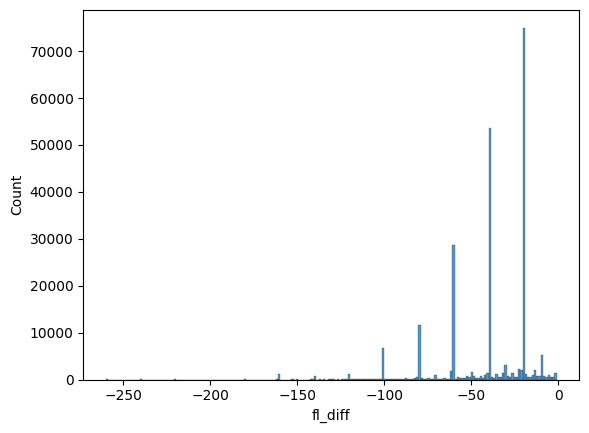

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.histplot(merged.query("fl_diff < 0")["fl_diff"])

<Axes: xlabel='fl_diff', ylabel='Count'>

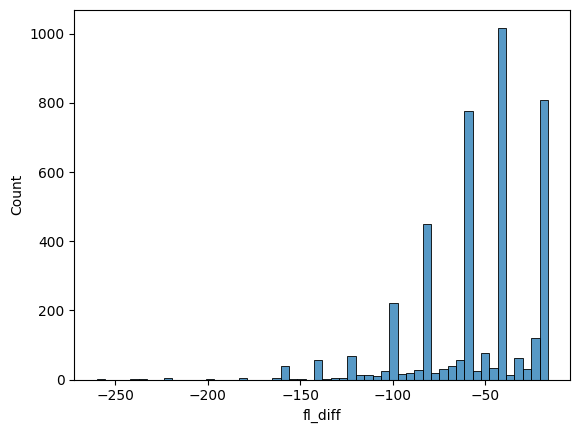

In [19]:
fl_diff = merged.groupby("flight_id")["fl_diff"].min().sort_values(ascending=True).reset_index()
sns.histplot(merged.groupby("flight_id")["fl_diff"].min())

Text(0, 0.5, 'Maximum flight level change along trajectory [FL]')

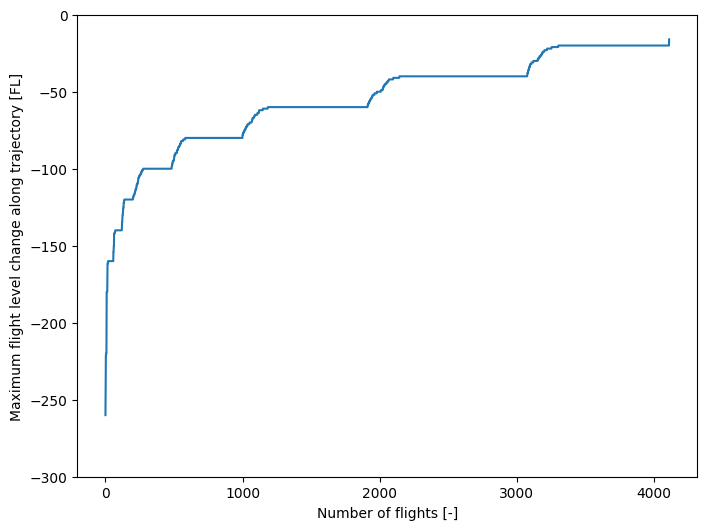

In [20]:
fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(np.arange(fl_diff.shape[0]), fl_diff["fl_diff"])
ax.set_ylim(-300, 0)
ax.set_xlabel("Number of flights [-]")
ax.set_ylabel("Maximum flight level change along trajectory [FL]")

In [21]:
fl_diff["bins_10"] = (fl_diff["fl_diff"] // 10) * 10
fl_diff.query("bins_10 >= -100").shape[0] / fl_diff.shape[0] #["bins_10"]#.value_counts()  # 93.3% are with a maximum FL change of 100 FL
fl_diff["bins_10"].value_counts()  # with the biggest ones being -40 (-40 to -31), -20 (-20 to -11), -60 (-60 to -51) (covering 62.8%), -80 (covering 74.2%), and -100

bins_10
-40     977
-20     809
-60     796
-80     469
-100    234
-30     182
-50     164
-70     133
-120     91
-90      73
-140     53
-110     46
-160     42
-130     13
-150     11
-170      5
-180      5
-220      3
-240      2
-230      2
-210      1
-260      1
Name: count, dtype: int64

In [22]:
from src.trajectory import cruise_blocks, classify_optimization

cb = pd.merge(
    dff.groupby("flight_id").apply(lambda d: cruise_blocks(d.fl.values)).rename("cruise_blocks"),
    dfo.groupby("flight_id").apply(lambda d: cruise_blocks(d.fl.values)).rename("cruise_blocks"),
    left_index=True, right_index=True,
    suffixes=("_f", "_o")
).reset_index()

cb["optimization_type"] = cb.apply(lambda d: classify_optimization(d.cruise_blocks_f, d.cruise_blocks_o), axis=1)

# meta = pd.merge(
#     meta,
#     cb,
#     on="flight_id"
# )

/var/folders/rf/y26fjyd9451bv4jwfbfwvy_j1vr8st/T/ipykernel_17156/2850634050.py:4: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  dff.groupby("flight_id").apply(lambda d: cruise_blocks(d.fl.values)).rename("cruise_blocks"),
/var/folders/rf/y26fjyd9451bv4jwfbfwvy_j1vr8st/T/ipykernel_17156/2850634050.py:5: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  dfo.groupby("flight_id").apply(lambda d: cruise_blocks(d.fl.values)).r

In [23]:
# cb[cb["optimization_type"].isna()]

In [24]:
cb.query("optimization_type == 'cruise_dip'")["cruise_blocks_o"]

1                               [360, 380, 340, 260, 250]
3                               [300, 360, 320, 360, 380]
4           [320, 330, 340, 350, 360, 380, 320, 380, 400]
7                     [350, 360, 280, 330, 340, 380, 400]
9                          [280, 340, 360, 350, 330, 350]
                              ...                        
4103                  [320, 340, 360, 300, 360, 370, 380]
4107                                 [350, 370, 330, 370]
4108                            [390, 370, 390, 410, 450]
4109                                 [350, 370, 350, 390]
4111    [310, 320, 340, 350, 340, 350, 340, 300, 340, ...
Name: cruise_blocks_o, Length: 1717, dtype: object

<Axes: >

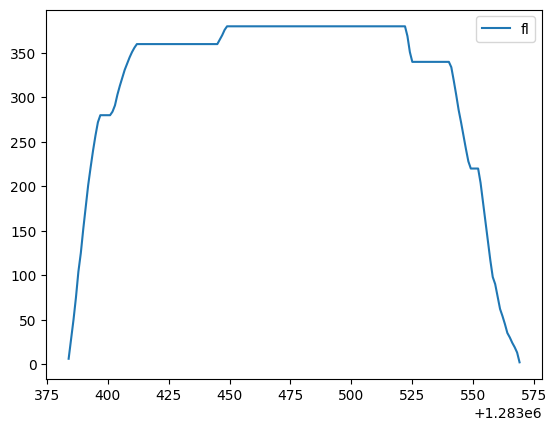

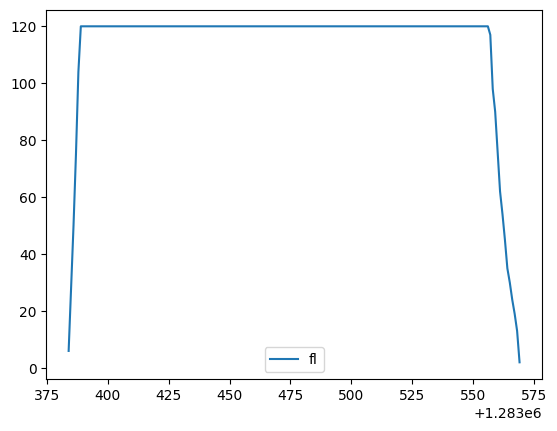

In [27]:
# fid = '00eeffe013ecc8cb8745d5349f51d8374b59b66e'
fid = '01b2058dc3b6477a97be8a974147aca7524139be'
fid = '01cac52f03fb554fd4838144f56e0fcc394e5e08'
fid = 'f001cec7a011552c9a3d6aa68e874d2bbea3f5b0'
dff.query("flight_id == @fid")[["fl"]].plot()
dfo.query("flight_id == @fid")[["fl"]].plot()

In [28]:
import numpy as np

def find_local_min(arr):
    arr = np.asarray(arr)
    idx = np.where((arr[1:-1] < arr[:-2]) & (arr[1:-1] < arr[2:]))[0]
    return arr[idx + 1], arr[idx + 1] - arr[idx]  # +1 because we skipped the first element

In [29]:
cb["local_min_f"] = cb["cruise_blocks_f"].apply(find_local_min)
cb["local_min_o"] = cb["cruise_blocks_o"].apply(find_local_min)
cb

,flight_id,cruise_blocks_f,cruise_blocks_o,optimization_type,local_min_f,local_min_o
0,00016e52b905f9d631587b31d70f56c53d9265e9,[340],"[320, 340]",late_climb,"([], [])","([], [])"
1,0014afdab57bc8e86c75072948714ff147f04f00,"[360, 380, 260, 250]","[360, 380, 340, 260, 250]",cruise_dip,"([], [])","([], [])"
2,001c15b9e58f24e260662e6966a91357a82816be,[300],[220],no_full_climb,"([], [])","([], [])"
3,002b71796263c77b9f6a13a36159ee6f25fb266c,"[300, 360, 380]","[300, 360, 320, 360, 380]",cruise_dip,"([], [])","([320], [-40])"
4,0043174ce1850ac24bda1223318404f333b3e2ec,"[320, 330, 340, 350, 360, 380, 400]","[320, 330, 340, 350, 360, 380, 320, 380, 400]",cruise_dip,"([], [])","([320], [-60])"
...,...,...,...,...,...,...
4107,ffc0fc0ab6d2e5ffc27df9932fe1adf1af2f600c,"[350, 370]","[350, 370, 330, 370]",cruise_dip,"([], [])","([330], [-40])"
4108,ffca9531cd382e1bc97b347885ad8aa6cd45a6b3,"[390, 410, 450]","[390, 370, 390, 410, 450]",cruise_dip,"([], [])","([370], [-20])"
4109,ffcc86169f1e7dc6d5388c43b8cf6ce17435f191,"[350, 370, 390]","[350, 370, 350, 390]",cruise_dip,"([], [])","([350], [-20])"
4110,ffdd25a5fc8769e9622754adea684cd71deb185a,"[360, 380, 370]","[300, 380, 370]",late_climb,"([], [])","([], [])"


In [30]:
cb[cb["local_min_f"].apply(lambda x: len(x[0]) > 0)]

,flight_id,cruise_blocks_f,cruise_blocks_o,optimization_type,local_min_f,local_min_o
6,004886b1a3b8f1ec78cff2c1706b9732e00a1ade,"[360, 370, 390, 410, 390, 410]","[260, 360, 370, 390, 410, 390, 410]",late_climb,"([390], [-20])","([390], [-20])"
7,00491b419039e4c75ffb3d775090f3169c02ae3c,"[350, 360, 340, 330, 340, 380, 400]","[350, 360, 280, 330, 340, 380, 400]",cruise_dip,"([330], [-10])","([280], [-80])"
8,005a2e8afe3f0c84b977696632d848a2a6dba583,"[340, 360, 320, 380]","[280, 360, 320, 380]",late_climb,"([320], [-40])","([320], [-40])"
15,00eeffe013ecc8cb8745d5349f51d8374b59b66e,"[360, 350, 330, 350]","[360, 350, 330, 350, 230]",early_descent,"([330], [-20])","([330], [-20])"
25,01b2058dc3b6477a97be8a974147aca7524139be,"[350, 360, 370, 360, 380, 400]","[350, 360, 370, 360, 300, 360, 380, 400]",cruise_dip,"([360], [-10])","([300], [-60])"
...,...,...,...,...,...,...
4050,fc0625108e46900986e62c3343e2772bdb5cd885,"[390, 410, 370, 410]","[390, 410, 370, 330, 410]",cruise_dip,"([370], [-40])","([330], [-40])"
4062,fd1756a7d4f8b0bc3606ad68d4e0d9803621cde2,"[360, 380, 370, 390]","[200, 360, 380, 370, 390]",late_climb,"([370], [-10])","([370], [-10])"
4086,fe9cbe5a43b916d7fb8cd329c44fc29f4a5b30ec,"[330, 290, 330, 350, 370]","[330, 290, 330, 290, 370]",cruise_dip,"([290], [-40])","([290, 290], [-40, -40])"
4101,ff6dcde2a6503a717683a86112eadd0e90730d12,"[350, 370, 350, 390]","[350, 370, 350, 390, 310, 390]",cruise_dip,"([350], [-20])","([350, 310], [-20, -80])"


In [31]:
cb[cb["local_min"].apply(len).gt(0)].query("optimization_type != 'cruise_dip'")

KeyError: 'local_min'

## Total fuel burn and NOx emissions

In [41]:
df = pd.read_parquet("../data/concerto_sol2_ex2_diff_agg_results.parquet")

<Axes: >

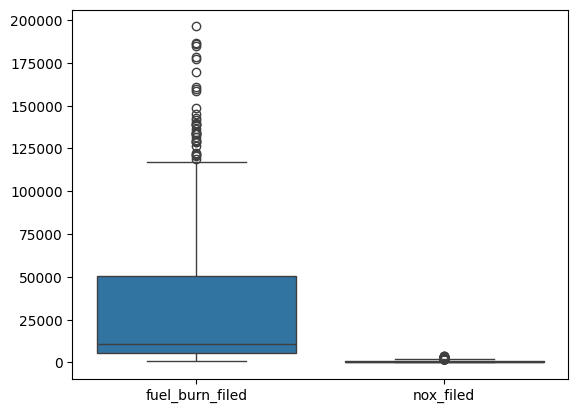

In [33]:
sns.boxplot(df[["fuel_burn_filed", "nox_filed"]])

In [42]:
kg_to_Tg = 1e-9
kg_to_tons = 1e-3

df[["fuel_burn_filed", "nox_filed"]].sum() * kg_to_tons

fuel_burn_filed    123008.096517
nox_filed            2060.018833
dtype: float64

In [43]:
df[["fuel_burn_filed", "nox_filed"]].mean()

fuel_burn_filed    29914.420359
nox_filed            500.977343
dtype: float64

In [24]:
dff = pd.read_parquet("../data/concerto_sol2_ex2_filed_wpts_results.parquet")

In [34]:
df = dff[["latitude", "longitude", "altitude_ft", "fuel_burn", "fir"]].query("fir.notnull()")

# fig, ax = plt.subplots(figsize=(8, 6))


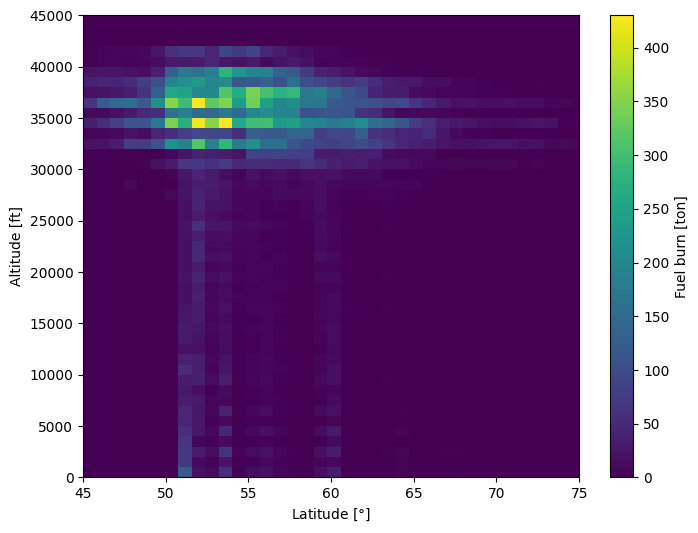

In [52]:
plt.figure(figsize=(8, 6))

h = plt.hist2d(
    df["latitude"],
    df["altitude_ft"],
    bins=45,
    weights=df["fuel_burn"] / 1e3,  # frequency weighted by fuel burn
    cmap="viridis"
)

plt.colorbar(label="Fuel burn [ton]")
plt.xlabel("Latitude [$\degree$]")
plt.ylabel("Altitude [ft]")

plt.xlim([45,75])
# plt.ylim([0,45000])
# plt.title("Fuel Burn Histogram")

plt.savefig("../reports/fuel_burn_histogram_filed.png", dpi=300, bbox_inches="tight")

## Flight distance in Borealis

In [44]:
meta = pd.read_parquet("../data/concerto_sol2_ex2_filed_meta.parquet")
meta.flown_distance.sum()

np.float64(19494388.945235953)

In [45]:
df[["fuel_burn_filed", "nox_filed"]].sum() / meta.flown_distance.sum() # kg

fuel_burn_filed    6.309923
nox_filed          0.105672
dtype: float64

In [3]:
dff = pd.read_parquet("../data/concerto_sol2_ex2_filed_wpts_results.parquet")
dff

,waypoint,flight_id,typecode,timestamp,latitude,longitude,fl,altitude_ft,pressure,true_airspeed,...,atr20_co2,atr20_contrail,atr20_h2o,atr20_o3,atr20_ch4,atr20_nox,atr20_non_co2,atr20_total,day_pair,fir
0,1,001c15b9e58f24e260662e6966a91357a82816be,BCS3,2023-03-19 21:38:00,56.906450,23.968356,0,0.0,1013.250000,72.701912,...,9.548247e-14,0.0,0.0,0.0,0.0,0.0,0.0,9.548247e-14,1,EVRR
1,2,001c15b9e58f24e260662e6966a91357a82816be,BCS3,2023-03-19 21:39:00,56.949956,23.975458,26,2600.0,921.552595,79.395886,...,9.399978e-14,0.0,0.0,0.0,0.0,0.0,0.0,9.399978e-14,1,EVRR
2,3,001c15b9e58f24e260662e6966a91357a82816be,BCS3,2023-03-19 21:40:00,57.002054,23.983991,48,4800.0,849.319832,107.375705,...,8.246769e-14,0.0,0.0,0.0,0.0,0.0,0.0,8.246769e-14,1,EVRR
3,4,001c15b9e58f24e260662e6966a91357a82816be,BCS3,2023-03-19 21:41:00,57.072414,23.997337,73,7300.0,772.874002,140.756554,...,7.776594e-14,0.0,0.0,0.0,0.0,0.0,0.0,7.776594e-14,1,EVRR
4,5,001c15b9e58f24e260662e6966a91357a82816be,BCS3,2023-03-19 21:42:00,57.151674,24.039706,105,10500.0,683.251498,156.756410,...,7.589971e-14,0.0,0.0,0.0,0.0,0.0,0.0,7.589971e-14,1,EVRR
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1370982,943,ffde818129b21ac9a5e957ffbf32dcc6f9b2229e,A388,2023-12-27 20:22:00,33.978994,-118.211254,18,1800.0,949.019946,88.857693,...,6.994224e-14,0.0,0.0,0.0,0.0,0.0,0.0,6.994224e-14,8,None
1370983,944,ffde818129b21ac9a5e957ffbf32dcc6f9b2229e,A388,2023-12-27 20:23:00,33.971339,-118.267845,14,1400.0,963.000070,83.538064,...,7.736804e-14,0.0,0.0,0.0,0.0,0.0,0.0,7.736804e-14,8,None
1370984,945,ffde818129b21ac9a5e957ffbf32dcc6f9b2229e,A388,2023-12-27 20:24:00,33.964091,-118.321224,10,1000.0,977.146488,82.561773,...,1.014881e-13,0.0,0.0,0.0,0.0,0.0,0.0,1.014881e-13,8,None
1370985,946,ffde818129b21ac9a5e957ffbf32dcc6f9b2229e,A388,2023-12-27 20:25:00,33.957073,-118.372766,6,600.0,991.460710,79.142818,...,1.187033e-13,0.0,0.0,0.0,0.0,0.0,0.0,1.187033e-13,8,None


In [4]:
from src.trajectory import flown_distance

res = pd.merge(
    df,
    dff.query("fir.notnull()").groupby("flight_id").progress_apply(
        lambda d: flown_distance(d.latitude, d.longitude) / 1000).rename("flown_distance").reset_index(),  # km
    on="flight_id",
    how="left"
)

100%|█████████▉| 4102/4112 [00:22<00:00, 195.97it/s]/Users/jsmretschnig/sourcetree/jecats-paper-climate-mitigation/.venv/lib/python3.11/site-packages/tqdm/std.py:917: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  return getattr(df, df_function)(wrapper, **kwargs)
100%|██████████| 4112/4112 [00:22<00:00, 180.79it/s]


In [7]:
res[["flown_distance_x", "flown_distance_y"]].sum().values

array([19494388.94523595,  5727992.47387177])

In [9]:
res.flown_distance_y.sum() / res.flown_distance_x.sum()  # 29.4% of flight segments are within Borealis

np.float64(0.29382775166551617)

In [12]:
df.typecode.nunique()

61

In [13]:
dff.head()

,waypoint,flight_id,typecode,timestamp,latitude,longitude,fl,altitude_ft,pressure,true_airspeed,...,atr20_co2,atr20_contrail,atr20_h2o,atr20_o3,atr20_ch4,atr20_nox,atr20_non_co2,atr20_total,day_pair,fir
0,1,001c15b9e58f24e260662e6966a91357a82816be,BCS3,2023-03-19 21:38:00,56.906450,23.968356,0,0.0,1013.250000,72.701912,...,9.548247e-14,0.0,0.0,0.0,0.0,0.0,0.0,9.548247e-14,1,EVRR
1,2,001c15b9e58f24e260662e6966a91357a82816be,BCS3,2023-03-19 21:39:00,56.949956,23.975458,26,2600.0,921.552595,79.395886,...,9.399978e-14,0.0,0.0,0.0,0.0,0.0,0.0,9.399978e-14,1,EVRR
2,3,001c15b9e58f24e260662e6966a91357a82816be,BCS3,2023-03-19 21:40:00,57.002054,23.983991,48,4800.0,849.319832,107.375705,...,8.246769e-14,0.0,0.0,0.0,0.0,0.0,0.0,8.246769e-14,1,EVRR
3,4,001c15b9e58f24e260662e6966a91357a82816be,BCS3,2023-03-19 21:41:00,57.072414,23.997337,73,7300.0,772.874002,140.756554,...,7.776594e-14,0.0,0.0,0.0,0.0,0.0,0.0,7.776594e-14,1,EVRR
4,5,001c15b9e58f24e260662e6966a91357a82816be,BCS3,2023-03-19 21:42:00,57.151674,24.039706,105,10500.0,683.251498,156.756410,...,7.589971e-14,0.0,0.0,0.0,0.0,0.0,0.0,7.589971e-14,1,EVRR


In [47]:
4.49e12 / 60.94e9 # g km^{-1}

73.67902855267477

In [49]:
meta.groupby("typecode").size()

typecode
A20N    244
A306      3
A310      1
A318      2
A319    198
       ... 
GLF6     16
J328      1
MD11      4
P8        2
R135      1
Length: 61, dtype: int64

In [2]:
2.346e-13 / 3.16 # vs. 8.8e-14

7.424050632911391e-14

In [3]:
0.0065 / 0.21

0.030952380952380953

In [4]:
0.0151

0.0151

# Thales meeting Feb 3rd, 2026

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from tqdm import tqdm

tqdm.pandas()

In [2]:
from traffic.core import Traffic

In [3]:
meta = pd.read_parquet("../data/concerto_sol2_ex2_filed_meta.parquet")

In [4]:
meta # GUFI from AVD (Thales internal)

# flight_id: count
# remove columns with identification data: callsign, engine_uid
# remove typecode?

,flight_id,dep,dest,typecode,callsign,eobt,eta,day_pair,flight_time,flown_distance,engine_uid,fuel_use,co2eq_gwp_pulse_100_co2,co2eq_gwp_pulse_100_contrails,co2eq_gwp_pulse_100_total
0,1a93d083903f8ee435d00be91da7b67de1b43f9c,MPTO,EHAM,B77L,QTR8158,2023-03-17 20:55:00,2023-03-18 06:21:00,1,0 days 09:10:24,9004.370043,01P21GE216,69256.268006,218965.963605,62366.335315,281332.298920
1,fc961030c4cf2d332febec17d3854362f61e2d57,LLBG,KSFO,B772,UAL955,2023-03-17 22:05:00,2023-03-18 12:40:00,1,0 days 14:17:54,12199.600985,2RR027,85269.554286,269661.854337,279346.917887,549008.772224
2,b6264318898756dc85ed90f280def58cdebc1d72,ZGGG,EBLG,B77L,ETH3647,2023-03-18 03:50:00,2023-03-18 16:01:00,1,0 days 11:55:31,9857.125828,01P21GE216,87405.287695,276348.586139,359794.441016,636143.027155
3,334e96a8d87ff95813b29a019a67155b8bfdc3c3,ZBAA,EDDF,B77W,CCA931,2023-03-18 05:00:00,2023-03-18 15:18:00,1,0 days 09:55:24,8035.504240,01P21GE217,76388.299257,241516.695591,252834.548508,494351.244100
4,0f1c80d87228eed8e6dcb729391a1035d31ef2c6,ELLX,MMMX,B744,CLX6686,2023-03-18 07:20:00,2023-03-18 19:06:00,1,0 days 11:29:09,10059.618959,01P02GE186,107176.118716,338693.889498,-258018.313997,80675.575501
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4107,db90f810e400ecd8bb15fd4eda6ddd7e537dd4da,EHAM,ZSPD,B77L,CSN496,2023-12-28 19:28:00,2023-12-29 05:55:00,8,0 days 10:04:38,9335.296615,01P21GE216,76797.434963,242863.899380,485697.807216,728561.706596
4108,aab5501e43fd5cc5e5569add64605b9ab38595df,ENGM,EKCH,A306,BCS3317,2023-12-28 19:38:00,2023-12-28 21:05:00,8,0 days 00:54:46.796000,588.464439,1PW048,4853.563458,15480.904121,83370.454125,98851.358246
4109,a9cd4811d4d9413834d43293c8bcd97c65fec9d4,GCTS,EIDW,A320,EIN76HJ,2023-12-28 19:50:00,2023-12-28 23:58:00,8,0 days 03:51:20,3104.901208,01P08CM105,8725.303091,27604.400435,287080.710102,314685.110537
4110,ff1744251a9734eef08e5a3bafd79a6a9841d5c1,LPPT,EIDW,B738,RYR1YW,2023-12-28 21:05:00,2023-12-28 23:31:00,8,0 days 02:16:46,1786.378808,01P11CM116,5410.277175,17143.485832,471171.781767,488315.267599


In [20]:
meta.query("dep == 'EHAM' and typecode == 'A320' and dest == 'ENGM'").iloc[0].to_dict()

{'flight_id': '047cd693fecdfce4495b4b6209e047bfc8e9eb74',
 'dep': 'EHAM',
 'dest': 'ENGM',
 'typecode': 'A320',
 'callsign': 'SAS822',
 'eobt': Timestamp('2023-12-17 11:49:00'),
 'eta': Timestamp('2023-12-17 13:25:00'),
 'day_pair': 6,
 'flight_time': Timedelta('0 days 01:27:18'),
 'flown_distance': 1103.4771400138065,
 'engine_uid': '01P08CM105',
 'fuel_use': 3415.1489170810046,
 'co2eq_gwp_pulse_100_co2': 10806.443681517165,
 'co2eq_gwp_pulse_100_contrails': 20909.768260529036,
 'co2eq_gwp_pulse_100_total': 31716.2119420462}

In [9]:
df = pd.read_parquet("../data/concerto_sol2_ex2_filed_wpts.parquet")
df = pd.read_parquet("../data/concerto_sol2_ex2_filed_wpts_results.parquet")

# trajectory from ECTL with internal algorithm
# trajectories are built from ECTL flight plans (not public source) using BADA3
# fuel_flow / fuel_burn from BADA
# typecode + fuel flow?

# Robin (CONCERTO)?
# approval from SESAR JU team

In [24]:
df = pd.read_parquet("../../phd-getting-started/paper_nox/data/dff_matthes_2025_dahlmann_2025_EAGWP100_[150, 350]_True.parquet")

In [28]:
df.query("flight_id == '047cd693fecdfce4495b4b6209e047bfc8e9eb74'")[["fuel_burn", "nox", "co2", "CoCiP", "NOx", "H2O"]].sum()

fuel_burn     3506.768321
nox             44.234444
co2          11077.881126
CoCiP         8139.085863
NOx           1735.499198
H2O            101.974274
dtype: float64

In [33]:
df.query("flight_id == '047cd693fecdfce4495b4b6209e047bfc8e9eb74'").iloc[30].to_dict()

{'waypoint': 31,
 'flight_id': '047cd693fecdfce4495b4b6209e047bfc8e9eb74',
 'typecode': 'A320',
 'timestamp': Timestamp('2023-12-17 12:37:00'),
 'latitude': 55.35380826107571,
 'longitude': 6.573458843206808,
 'fl': 370,
 'altitude_ft': 37000.0,
 'pressure': 216.37890049453623,
 'true_airspeed': 226.537784761383,
 'mach': 0.7677438357565026,
 'air_temperature': 213.34689331054688,
 'specific_humidity': 2.4307379135279916e-05,
 'u_wind': 31.579626083374023,
 'v_wind': 0.20259983837604523,
 'geopotential': 113246.7265625,
 'potential_vorticity': 4.544808263062805e-08,
 'relative_humidity': 77.30816650390625,
 'aCCF_O3': 2.8627840115841297e-12,
 'aCCF_CH4': -7.710290367436158e-13,
 'aCCF_NOx': 2.0917550358330436e-12,
 'aCCF_H2O': 4.1299378332341e-16,
 'aCCF_CO2': 7.48e-16,
 'aircraft_mass': 61997.4832294912,
 'fuel_flow': 0.6205461977229266,
 'engine_efficiency': 0.3656943250572867,
 'APModel': 'BADA3',
 'altitude': 11277.6,
 'level': 216.62374173827783,
 'air_pressure': 21662.37417382778

In [11]:
df.columns

Index(['waypoint', 'flight_id', 'typecode', 'timestamp', 'latitude',
       'longitude', 'fl', 'altitude_ft', 'pressure', 'true_airspeed', 'mach',
       'air_temperature', 'specific_humidity', 'u_wind', 'v_wind',
       'geopotential', 'potential_vorticity', 'relative_humidity', 'aCCF_O3',
       'aCCF_CH4', 'aCCF_NOx', 'aCCF_H2O', 'aCCF_CO2', 'aircraft_mass',
       'APModel', 'fuel_flow', 'engine_efficiency', 'thrust_setting', 'nox_ei',
       'nox', 'fuel_burn', 'co2', 'co2eq_co2', 'co2eq_contrail', 'co2eq_h2o',
       'co2eq_o3', 'co2eq_ch4', 'co2eq_nox', 'co2eq_non_co2', 'co2eq_total',
       'atr20_co2', 'atr20_contrail', 'atr20_h2o', 'atr20_o3', 'atr20_ch4',
       'atr20_nox', 'atr20_non_co2', 'atr20_total', 'day_pair', 'fir'],
      dtype='object')

In [7]:
fid = meta.sample(1).flight_id.values[0]

sf = df.query("flight_id == @fid")

In [9]:
fid

'005a2e8afe3f0c84b977696632d848a2a6dba583'

In [10]:
print(fid)
t = Traffic(sf)
t.map_leaflet()

005a2e8afe3f0c84b977696632d848a2a6dba583


Map(center=[np.float64(47.314348477701294), np.float64(-38.61402148833052)], controls=(ZoomControl(options=['p…